In [1]:
from IPython.display import Markdown, display
display(Markdown("""# Quantum Machine Learning for Lithium-Ion Battery Materials Discovery

**Presentation notebook**

Goal: identify lithium-ion battery material candidates using Materials Project
data, XGBoost, India-focused screening, and a first QML baseline.
"""))

# Quantum Machine Learning for Lithium-Ion Battery Materials Discovery

**Presentation notebook**

Goal: identify lithium-ion battery material candidates using Materials Project
data, XGBoost, India-focused screening, and a first QML baseline.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

project_folder = Path.cwd()
processed_folder = project_folder / "data" / "processed"

lithium_scored_dataframe = pd.read_csv(processed_folder / "lithium india scored.csv")
final_shortlist_dataframe = pd.read_csv(processed_folder / "final india battery shortlist.csv")
dss_family_ranking_dataframe = pd.read_csv(processed_folder / "dss battery family recommendation ranking.csv")
dss_material_ranking_dataframe = pd.read_csv(processed_folder / "dss material recommendation ranking.csv")
qml_ready_dataframe = pd.read_csv(processed_folder / "qml_ready_lithium_india.csv")
qml_predictions_dataframe = pd.read_csv(processed_folder / "qml baseline predictions.csv")
tuned_qml_predictions_dataframe = pd.read_csv(processed_folder / "qml tuned best predictions.csv")
improved_qml_dataset_dataframe = pd.read_csv(processed_folder / "improved qml feature pca.csv")
improved_qml_tuning_results_dataframe = pd.read_csv(processed_folder / "improved qml tuning results.csv")
improved_qml_predictions_dataframe = pd.read_csv(processed_folder / "improved qml best predictions.csv")
improved_qml_threshold_results_dataframe = pd.read_csv(processed_folder / "improved qml threshold results.csv")
improved_qml_threshold_predictions_dataframe = pd.read_csv(processed_folder / "improved qml threshold predictions.csv")
improved_qml_alignment_scores_dataframe = pd.read_csv(processed_folder / "improved qml alignment scores.csv")
improved_qml_alignment_results_dataframe = pd.read_csv(processed_folder / "improved qml alignment results.csv")
improved_qml_alignment_predictions_dataframe = pd.read_csv(processed_folder / "improved qml alignment predictions.csv")
best_qml_repeated_split_results_dataframe = pd.read_csv(processed_folder / "best qml repeated split results.csv")
best_qml_repeated_split_predictions_dataframe = pd.read_csv(processed_folder / "best qml repeated split predictions.csv")
qml_vs_logistic_results_dataframe = pd.read_csv(processed_folder / "qml vs logistic repeated split results.csv")
qml_vs_logistic_summary_dataframe = pd.read_csv(processed_folder / "qml vs logistic repeated split summary.csv")
qml_vs_logistic_predictions_dataframe = pd.read_csv(processed_folder / "qml vs logistic repeated split predictions.csv")

dataset_summary = pd.DataFrame([
    {"dataset": "Lithium India scored", "rows": len(lithium_scored_dataframe), "columns": len(lithium_scored_dataframe.columns)},
    {"dataset": "Final India shortlist", "rows": len(final_shortlist_dataframe), "columns": len(final_shortlist_dataframe.columns)},
    {"dataset": "DSS family ranking", "rows": len(dss_family_ranking_dataframe), "columns": len(dss_family_ranking_dataframe.columns)},
    {"dataset": "DSS material ranking", "rows": len(dss_material_ranking_dataframe), "columns": len(dss_material_ranking_dataframe.columns)},
    {"dataset": "QML-ready dataset", "rows": len(qml_ready_dataframe), "columns": len(qml_ready_dataframe.columns)},
    {"dataset": "QML test predictions", "rows": len(qml_predictions_dataframe), "columns": len(qml_predictions_dataframe.columns)},
    {"dataset": "Tuned QML test predictions", "rows": len(tuned_qml_predictions_dataframe), "columns": len(tuned_qml_predictions_dataframe.columns)},
    {"dataset": "Improved QML PCA dataset", "rows": len(improved_qml_dataset_dataframe), "columns": len(improved_qml_dataset_dataframe.columns)},
    {"dataset": "Improved QML tuning results", "rows": len(improved_qml_tuning_results_dataframe), "columns": len(improved_qml_tuning_results_dataframe.columns)},
    {"dataset": "Improved QML test predictions", "rows": len(improved_qml_predictions_dataframe), "columns": len(improved_qml_predictions_dataframe.columns)},
    {"dataset": "Improved QML threshold results", "rows": len(improved_qml_threshold_results_dataframe), "columns": len(improved_qml_threshold_results_dataframe.columns)},
    {"dataset": "Improved QML threshold predictions", "rows": len(improved_qml_threshold_predictions_dataframe), "columns": len(improved_qml_threshold_predictions_dataframe.columns)},
    {"dataset": "Improved QML alignment scores", "rows": len(improved_qml_alignment_scores_dataframe), "columns": len(improved_qml_alignment_scores_dataframe.columns)},
    {"dataset": "Improved QML alignment results", "rows": len(improved_qml_alignment_results_dataframe), "columns": len(improved_qml_alignment_results_dataframe.columns)},
    {"dataset": "Improved QML alignment predictions", "rows": len(improved_qml_alignment_predictions_dataframe), "columns": len(improved_qml_alignment_predictions_dataframe.columns)},
    {"dataset": "Best QML repeated split results", "rows": len(best_qml_repeated_split_results_dataframe), "columns": len(best_qml_repeated_split_results_dataframe.columns)},
    {"dataset": "Best QML repeated split predictions", "rows": len(best_qml_repeated_split_predictions_dataframe), "columns": len(best_qml_repeated_split_predictions_dataframe.columns)},
    {"dataset": "QML vs Logistic results", "rows": len(qml_vs_logistic_results_dataframe), "columns": len(qml_vs_logistic_results_dataframe.columns)},
    {"dataset": "QML vs Logistic summary", "rows": len(qml_vs_logistic_summary_dataframe), "columns": len(qml_vs_logistic_summary_dataframe.columns)},
    {"dataset": "QML vs Logistic predictions", "rows": len(qml_vs_logistic_predictions_dataframe), "columns": len(qml_vs_logistic_predictions_dataframe.columns)},
])
display(dataset_summary)

dataset,rows,columns
Lithium India scored,24957,37
Final India shortlist,629,21
DSS family ranking,6,12
DSS material ranking,629,13
QML-ready dataset,1000,27
QML test predictions,200,11
Tuned QML test predictions,200,8
Improved QML PCA dataset,1000,14
Improved QML tuning results,162,13
Improved QML test predictions,200,8


stage,rows
Raw MP snapshot,210579
Lithium dataset,24957
QML-ready dataset,1000
Final shortlist,629


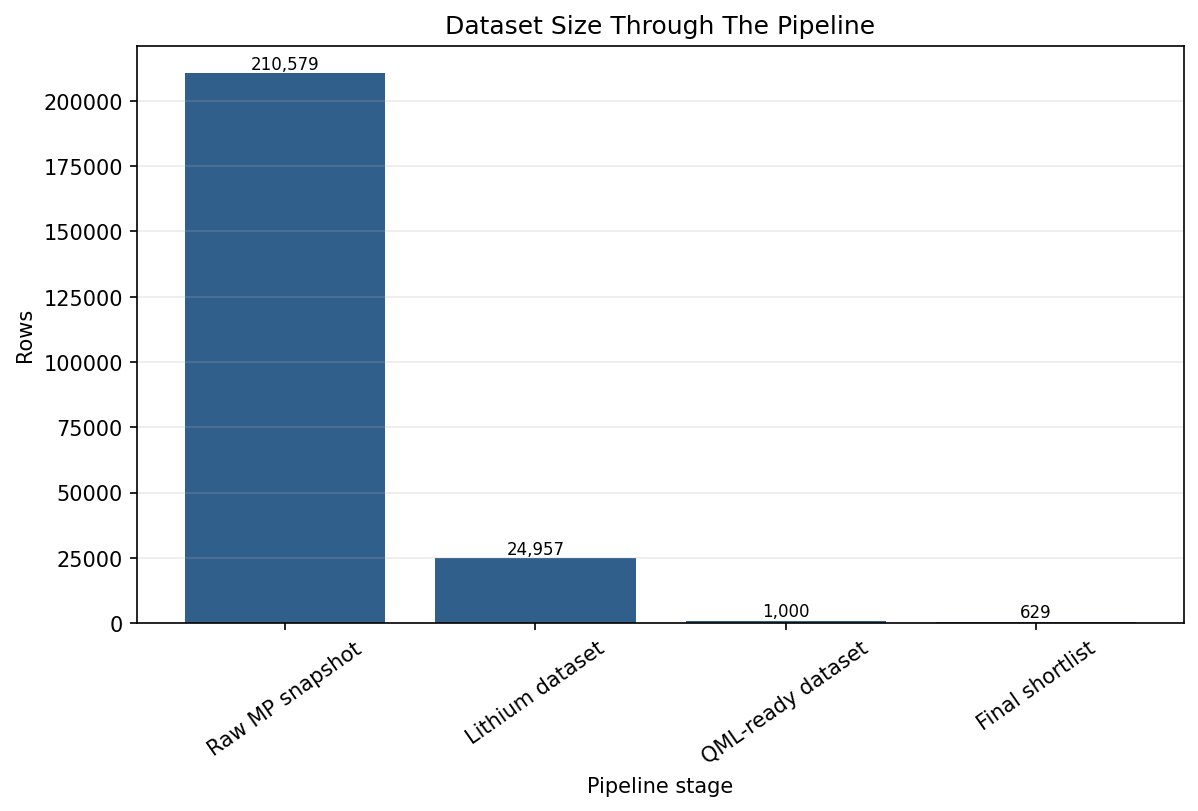

In [3]:
pipeline_counts_dataframe = pd.DataFrame([
    {"stage": "Raw MP snapshot", "rows": 210579},
    {"stage": "Lithium dataset", "rows": len(lithium_scored_dataframe)},
    {"stage": "QML-ready dataset", "rows": len(qml_ready_dataframe)},
    {"stage": "Final shortlist", "rows": len(final_shortlist_dataframe)},
])

plt.figure(figsize=(9, 5))
plt.bar(pipeline_counts_dataframe["stage"], pipeline_counts_dataframe["rows"])
plt.title("Dataset Size Through The Pipeline")
plt.xlabel("Pipeline stage")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

battery_family,rows
Other lithium material,14027
LCO-family,3541
LMO-family,3394
LTO-family,964
Li-S or sulfide-family,892
Silicon-family,852
LFP-family,735
Carbon-family,477


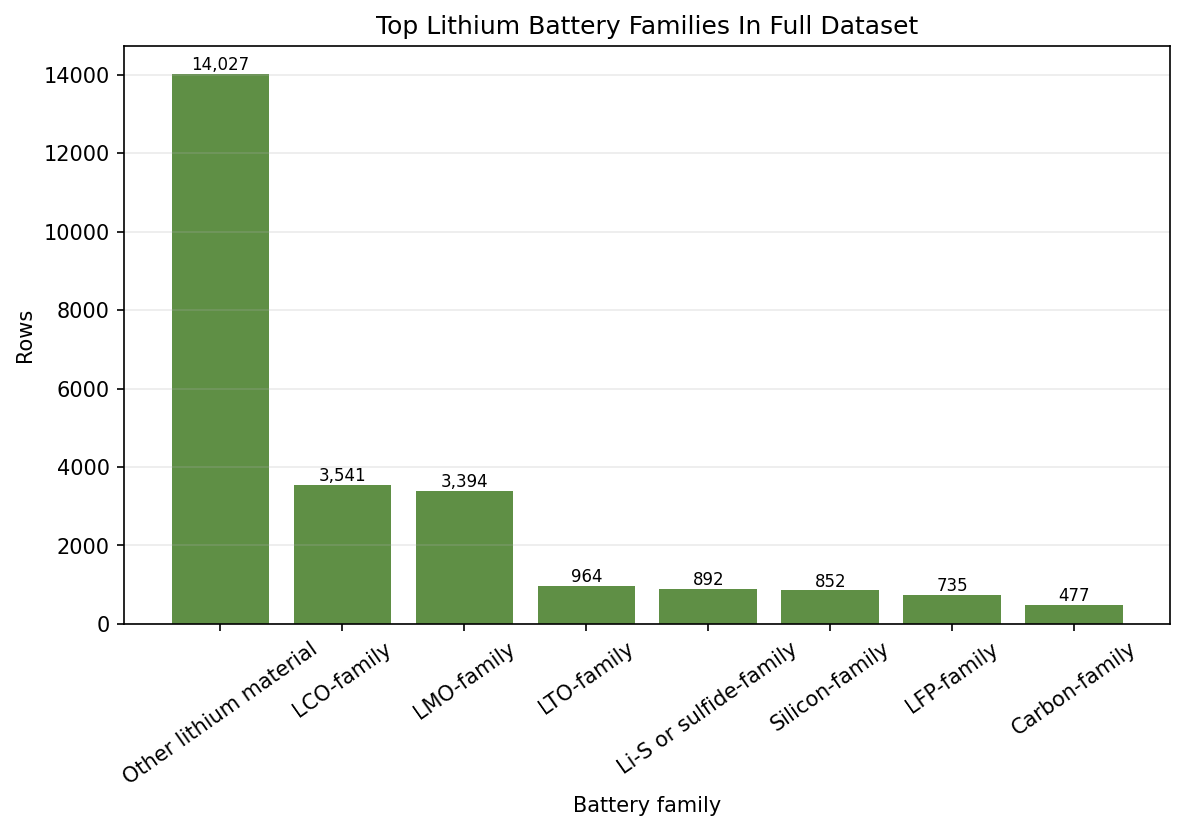

In [4]:
family_counts_dataframe = (
    lithium_scored_dataframe["battery_family"]
    .value_counts()
    .head(8)
    .reset_index()
)
family_counts_dataframe.columns = ["battery_family", "rows"]

display(family_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(family_counts_dataframe["battery_family"], family_counts_dataframe["rows"])
plt.title("Top Lithium Battery Families In Full Dataset")
plt.xlabel("Battery family")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

india_decision_label,rows
Caution,13524
Research Candidate,5883
Avoid / Benchmark,4370
Recommend,1180


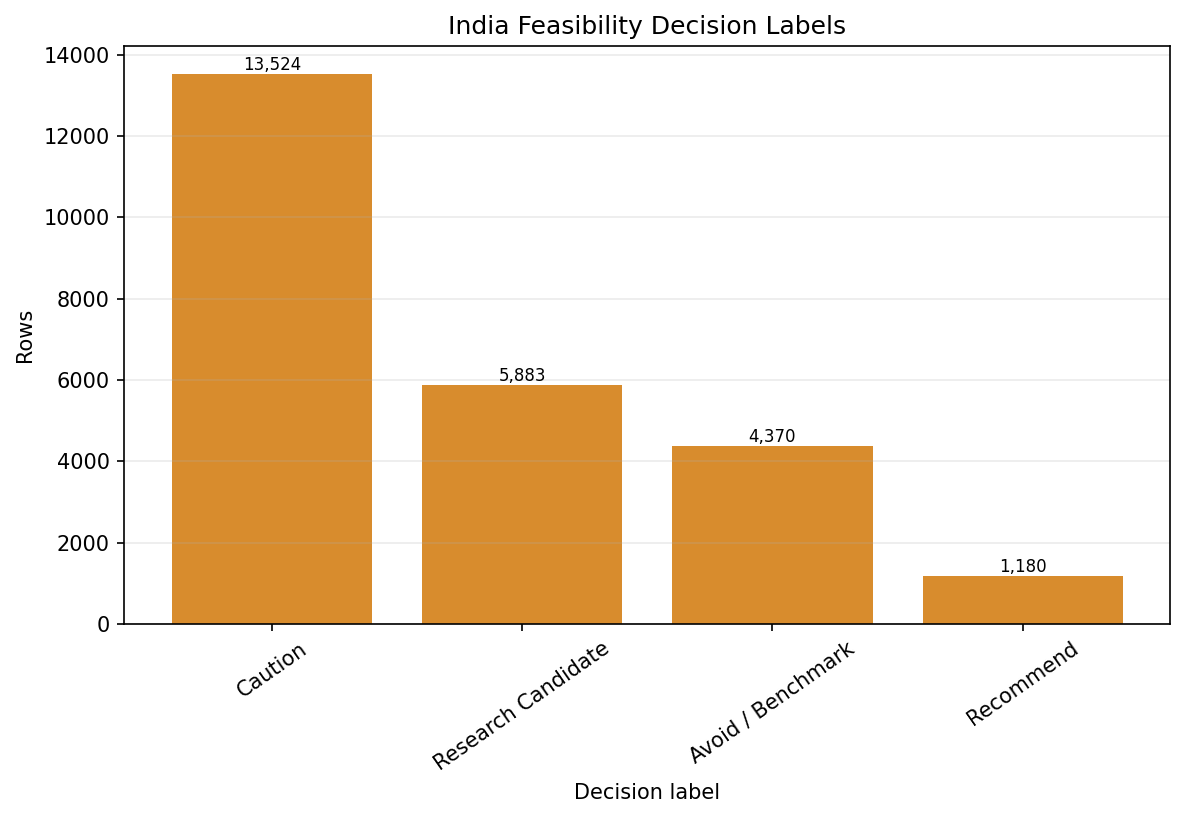

In [5]:
decision_counts_dataframe = (
    lithium_scored_dataframe["india_decision_label"]
    .value_counts()
    .reset_index()
)
decision_counts_dataframe.columns = ["india_decision_label", "rows"]

display(decision_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(decision_counts_dataframe["india_decision_label"], decision_counts_dataframe["rows"])
plt.title("India Feasibility Decision Labels")
plt.xlabel("Decision label")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

battery_family,rows
LFP-family,464
Li-S or sulfide-family,91
LMFP-family,48
Silicon-family,17
Carbon-family,5
LMO-family,4


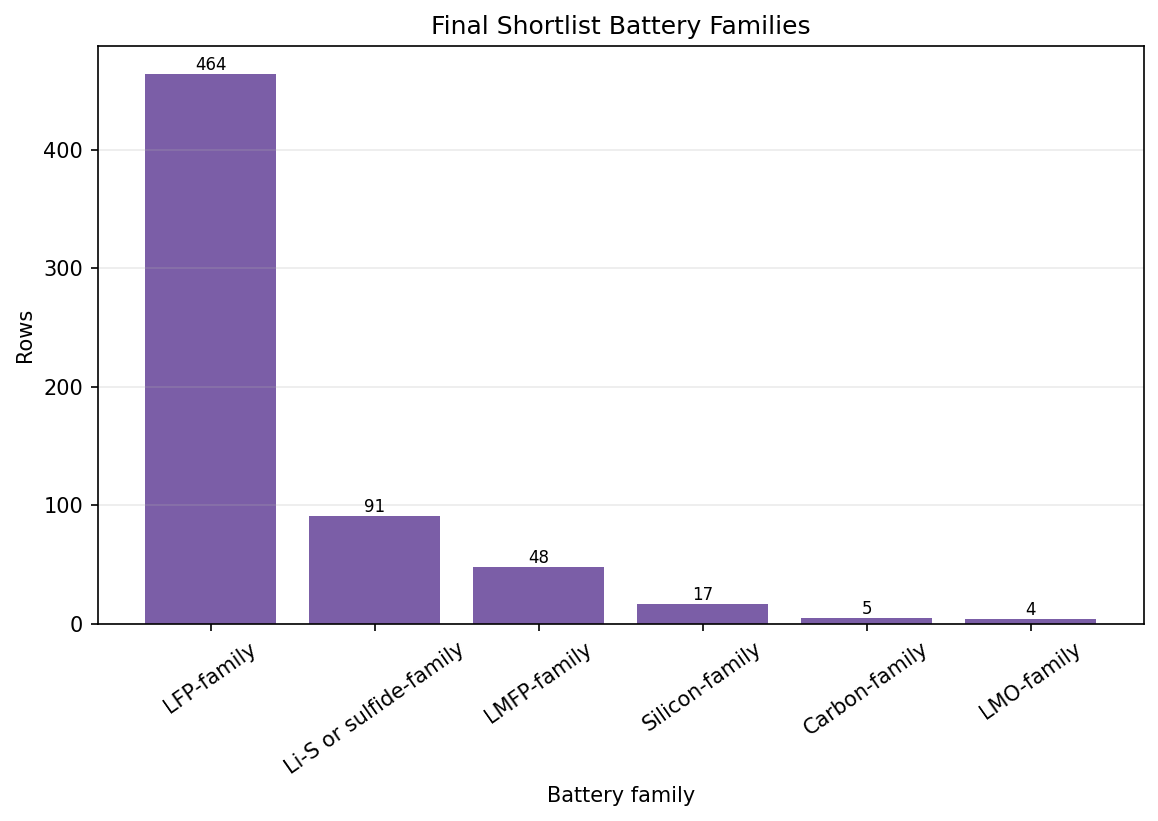

In [6]:
final_family_counts_dataframe = (
    final_shortlist_dataframe["battery_family"]
    .value_counts()
    .reset_index()
)
final_family_counts_dataframe.columns = ["battery_family", "rows"]

display(final_family_counts_dataframe)

plt.figure(figsize=(9, 5))
plt.bar(final_family_counts_dataframe["battery_family"], final_family_counts_dataframe["rows"])
plt.title("Final Shortlist Battery Families")
plt.xlabel("Battery family")
plt.ylabel("Rows")
plt.xticks(rotation=35)
plt.grid(axis="y", alpha=0.25)
plt.show()

In [7]:
top_candidate_columns = [
    "material_id",
    "formula",
    "battery_family",
    "india_decision_label",
    "shortlist_rule_type",
    "shortlist_score",
    "predicted_stable_probability",
    "predicted_energy_above_hull_clipped",
    "india_feasibility_score",
]
top_candidates_dataframe = final_shortlist_dataframe[top_candidate_columns].head(10)
display(top_candidates_dataframe)

material_id,formula,battery_family,india_decision_label,shortlist_rule_type,shortlist_score,predicted_stable_probability,predicted_energy_above_hull_clipped,india_feasibility_score
mp-19430,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,59.52,0.167670,0.011649,98
mp-554093,Li9Fe3P8O29,LFP-family,Recommend,Benchmark family exception,59.10,0.147220,0.009104,98
mp-1195117,LiFeP2(HO3)2,LFP-family,Recommend,Benchmark family exception,57.42,0.172900,0.016302,94
mp-19294,LiFeP2O7,LFP-family,Recommend,Benchmark family exception,57.26,0.222164,0.038672,100
mp-19017,LiFePO4,LFP-family,Recommend,Benchmark family exception,56.48,0.138139,0.023703,100
mp-26985,Li2Fe3(P2O7)2,LFP-family,Recommend,Benchmark family exception,56.39,0.115441,0.015525,98
mp-1198378,NaLiFePO4F,LFP-family,Recommend,Benchmark family exception,56.22,0.167278,0.021042,94
mp-6373,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,55.50,0.131681,0.023631,98
mp-25993,Li3Fe2(PO4)3,LFP-family,Recommend,Benchmark family exception,55.32,0.126405,0.023346,98
mp-504179,LiFe(PO3)3,LFP-family,Recommend,Benchmark family exception,54.88,0.132133,0.026851,98


In [8]:
display(Markdown("""## DSS Recommendation Ranking

The project is used as a Decision Support System here. The first table ranks
battery-material families for business decisions. The second table shows the
top material candidates and the parameters behind each rank.
"""))

dss_family_display_columns = [
    "dss_rank",
    "battery_family",
    "dss_decision",
    "shortlist_rows",
    "average_india_feasibility_score",
    "average_predicted_stable_probability",
    "median_predicted_energy_above_hull",
    "top_formula",
    "short_reason",
]
dss_family_display_dataframe = dss_family_ranking_dataframe[dss_family_display_columns]
display(dss_family_display_dataframe)

dss_material_display_columns = [
    "dss_rank",
    "material_id",
    "formula",
    "battery_family",
    "dss_decision",
    "shortlist_score",
    "india_feasibility_score",
    "predicted_stable_probability",
    "predicted_energy_above_hull_clipped",
    "short_conceptual_reason",
]
dss_material_display_dataframe = dss_material_ranking_dataframe[
    dss_material_display_columns
].head(10)
display(dss_material_display_dataframe)

## DSS Recommendation Ranking

The project is used as a Decision Support System here. The first table ranks
battery-material families for business decisions. The second table shows the
top material candidates and the parameters behind each rank.


dss_rank,battery_family,dss_decision,shortlist_rows,average_india_feasibility_score,average_predicted_stable_probability,median_predicted_energy_above_hull,top_formula,short_reason
1,LFP-family,Best near-term purchase direction,464,96.0259,0.0148,0.0487,Li3Fe2(PO4)3,India-friendly iron phosphate chemistry; avoids nickel and cobalt.
2,LMFP-family,Good pilot and next-generation option,48,94.2083,0.0094,0.0398,Na4Li4MnFe3P4(O4F)4,LFP-like family with manganese; useful for improving performance.
3,LMO-family,Selective low-cost option,4,89.2500,0.6783,0.0288,Li2MgMn3O8,"Manganese-based family; useful when cost matters, but needs checks."
4,Carbon-family,Useful anode/support material,5,94.8000,0.7261,0.0647,LiEr4MnC8,"Practical supporting material, but not a complete battery-cell choice."
5,Silicon-family,R&D anode improvement option,17,87.0000,0.7376,0.0151,SrLi2SiO4,High-potential anode direction; better for blended or future designs.
6,Li-S or sulfide-family,Long-term R&D option,91,78.0220,0.7928,0.0034,Li2MnGeS4,"High-potential chemistry, but less direct for immediate purchase."


dss_rank,material_id,formula,battery_family,dss_decision,shortlist_score,india_feasibility_score,predicted_stable_probability,predicted_energy_above_hull_clipped,short_conceptual_reason
1,mp-19430,Li3Fe2(PO4)3,LFP-family,Best near-term purchase direction,59.52,98,0.167670,0.011649,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 98; predicted hull 0.0116; stable probability 0.1677.
2,mp-554093,Li9Fe3P8O29,LFP-family,Best near-term purchase direction,59.10,98,0.147220,0.009104,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 98; predicted hull 0.0091; stable probability 0.1472.
3,mp-1195117,LiFeP2(HO3)2,LFP-family,Best near-term purchase direction,57.42,94,0.172900,0.016302,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 94; predicted hull 0.0163; stable probability 0.1729.
4,mp-19294,LiFeP2O7,LFP-family,Best near-term purchase direction,57.26,100,0.222164,0.038672,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 100; predicted hull 0.0387; stable probability 0.2222.
5,mp-19017,LiFePO4,LFP-family,Best near-term purchase direction,56.48,100,0.138139,0.023703,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 100; predicted hull 0.0237; stable probability 0.1381.
6,mp-26985,Li2Fe3(P2O7)2,LFP-family,Best near-term purchase direction,56.39,98,0.115441,0.015525,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 98; predicted hull 0.0155; stable probability 0.1154.
7,mp-1198378,NaLiFePO4F,LFP-family,Best near-term purchase direction,56.22,94,0.167278,0.021042,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 94; predicted hull 0.0210; stable probability 0.1673.
8,mp-6373,Li3Fe2(PO4)3,LFP-family,Best near-term purchase direction,55.50,98,0.131681,0.023631,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 98; predicted hull 0.0236; stable probability 0.1317.
9,mp-25993,Li3Fe2(PO4)3,LFP-family,Best near-term purchase direction,55.32,98,0.126405,0.023346,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 98; predicted hull 0.0233; stable probability 0.1264.
10,mp-504179,LiFe(PO3)3,LFP-family,Best near-term purchase direction,54.88,98,0.132133,0.026851,India-friendly iron phosphate chemistry; avoids nickel and cobalt. India score 98; predicted hull 0.0269; stable probability 0.1321.


In [9]:
quantum_parameters_dataframe = pd.DataFrame([
    {"parameter": "QML model type", "value": "Simulated quantum kernel classifier"},
    {"parameter": "Original number of qubits", "value": "10"},
    {"parameter": "Tuned number of qubits", "value": "8"},
    {"parameter": "Tuned quantum state size", "value": "256"},
    {"parameter": "Original feature encoding", "value": "angle = pi * scaled_feature_value"},
    {"parameter": "Tuned feature encoding", "value": "angle = (pi / 2) * scaled_feature_value"},
    {"parameter": "Single-qubit state", "value": "[cos(angle / 2), sin(angle / 2)]"},
    {"parameter": "Kernel formula", "value": "K(x, y) = |<phi(x), phi(y)>|^2"},
    {"parameter": "Classifier", "value": "SVC with precomputed kernel"},
    {"parameter": "Tuned SVM C value", "value": "1.0"},
    {"parameter": "Tuning method", "value": "4-fold cross-validation"},
    {"parameter": "Improved separate section", "value": "Random Forest feature importance + PCA + kernel tuning"},
    {"parameter": "Improved best qubits", "value": "6"},
    {"parameter": "Improved best kernel", "value": "entangled_pi"},
    {"parameter": "Improved best angle scale", "value": "pi"},
    {"parameter": "Improved best SVM C value", "value": "2.0"},
    {"parameter": "Threshold experiment", "value": "Stable-probability cutoff tuned by cross-validation"},
    {"parameter": "Best stable threshold", "value": "0.50"},
    {"parameter": "Kernel alignment experiment", "value": "Feature set selected by quantum kernel-target alignment"},
    {"parameter": "Alignment best feature set", "value": "rf_top_4"},
    {"parameter": "Alignment best qubits", "value": "4"},
    {"parameter": "Alignment best kernel", "value": "entangled_pi"},
    {"parameter": "Alignment best SVM C value", "value": "5.0"},
    {"parameter": "Train/test split", "value": "80/20"},
    {"parameter": "Random state", "value": "42"},
])
display(quantum_parameters_dataframe)

parameter,value
QML model type,Simulated quantum kernel classifier
Original number of qubits,10
Tuned number of qubits,8
Tuned quantum state size,256
Original feature encoding,angle = pi * scaled_feature_value
Tuned feature encoding,angle = (pi / 2) * scaled_feature_value
Single-qubit state,"[cos(angle / 2), sin(angle / 2)]"
Kernel formula,"K(x, y) = |<phi(x), phi(y)>|^2"
Classifier,SVC with precomputed kernel
Tuned SVM C value,1.0


qubit,feature,gate,angle
q0,formation_energy_per_atom,RY(theta_0),theta_0 = pi * scaled formation_energy_per_atom
q1,has_o,RY(theta_1),theta_1 = pi * scaled has_o
q2,space_group_number,RY(theta_2),theta_2 = pi * scaled space_group_number
q3,theoretical,RY(theta_3),theta_3 = pi * scaled theoretical


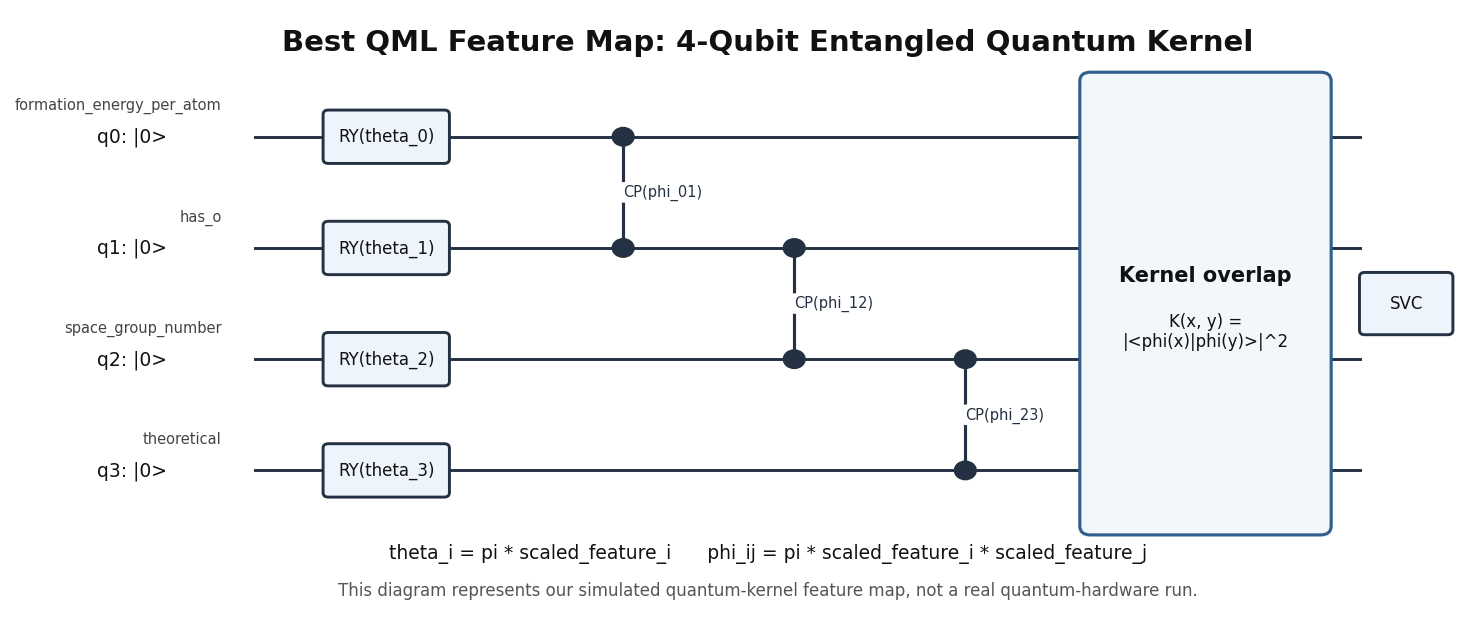

In [10]:
qml_circuit_dataframe = pd.DataFrame([
    {
        "qubit": "q0",
        "feature": "formation_energy_per_atom",
        "gate": "RY(theta_0)",
        "angle": "theta_0 = pi * scaled formation_energy_per_atom",
    },
    {
        "qubit": "q1",
        "feature": "has_o",
        "gate": "RY(theta_1)",
        "angle": "theta_1 = pi * scaled has_o",
    },
    {
        "qubit": "q2",
        "feature": "space_group_number",
        "gate": "RY(theta_2)",
        "angle": "theta_2 = pi * scaled space_group_number",
    },
    {
        "qubit": "q3",
        "feature": "theoretical",
        "gate": "RY(theta_3)",
        "angle": "theta_3 = pi * scaled theoretical",
    },
])
display(qml_circuit_dataframe)

qml_circuit_image = plt.imread(processed_folder / "qml circuit diagram.png")
plt.figure(figsize=(12, 5.2))
plt.imshow(qml_circuit_image)
plt.axis("off")
plt.show()

model,accuracy,stable_precision,stable_recall,stable_f1
QML quantum kernel,0.8100,0.7870,0.85,0.8173
Tuned QML quantum kernel,0.8200,0.7963,0.86,0.8269
Improved QML separate section,0.8150,0.7890,0.86,0.8230
Improved QML threshold tuning,0.8200,0.7963,0.86,0.8269
Improved QML kernel alignment,0.8200,0.7857,0.88,0.8302
XGBoost same QML data,0.8300,0.8367,0.82,0.8283
XGBoost full project,0.9091,0.7300,0.70,0.7100


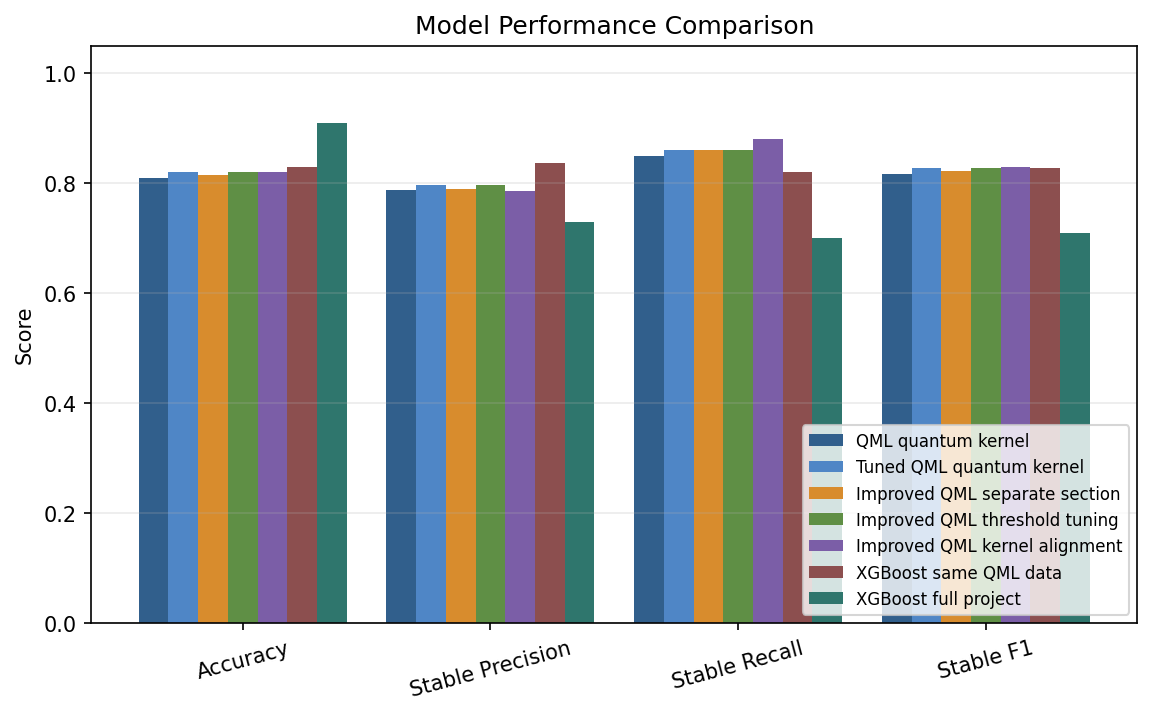

In [11]:
true_labels = qml_predictions_dataframe["target_is_stable"]
qml_predicted_labels = qml_predictions_dataframe["qml_predicted_label"]
xgboost_predicted_labels = qml_predictions_dataframe["xgboost_same_data_predicted_label"]
tuned_true_labels = tuned_qml_predictions_dataframe["target_is_stable"]
tuned_qml_predicted_labels = tuned_qml_predictions_dataframe["tuned_qml_predicted_label"]
improved_true_labels = improved_qml_predictions_dataframe["target_is_stable"]
improved_qml_predicted_labels = improved_qml_predictions_dataframe["improved_qml_predicted_label"]
threshold_true_labels = improved_qml_threshold_predictions_dataframe["target_is_stable"]
threshold_qml_predicted_labels = improved_qml_threshold_predictions_dataframe["threshold_qml_predicted_label"]
alignment_true_labels = improved_qml_alignment_predictions_dataframe["target_is_stable"]
alignment_qml_predicted_labels = improved_qml_alignment_predictions_dataframe["alignment_qml_predicted_label"]

metric_dataframe = pd.DataFrame([
    {
        "model": "QML quantum kernel",
        "accuracy": accuracy_score(true_labels, qml_predicted_labels),
        "stable_precision": precision_score(true_labels, qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(true_labels, qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(true_labels, qml_predicted_labels, zero_division=0),
    },
    {
        "model": "Tuned QML quantum kernel",
        "accuracy": accuracy_score(tuned_true_labels, tuned_qml_predicted_labels),
        "stable_precision": precision_score(tuned_true_labels, tuned_qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(tuned_true_labels, tuned_qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(tuned_true_labels, tuned_qml_predicted_labels, zero_division=0),
    },
    {
        "model": "Improved QML separate section",
        "accuracy": accuracy_score(improved_true_labels, improved_qml_predicted_labels),
        "stable_precision": precision_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0),
    },
    {
        "model": "Improved QML threshold tuning",
        "accuracy": accuracy_score(threshold_true_labels, threshold_qml_predicted_labels),
        "stable_precision": precision_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
    },
    {
        "model": "Improved QML kernel alignment",
        "accuracy": accuracy_score(alignment_true_labels, alignment_qml_predicted_labels),
        "stable_precision": precision_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0),
        "stable_recall": recall_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0),
        "stable_f1": f1_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0),
    },
    {
        "model": "XGBoost same QML data",
        "accuracy": accuracy_score(true_labels, xgboost_predicted_labels),
        "stable_precision": precision_score(true_labels, xgboost_predicted_labels, zero_division=0),
        "stable_recall": recall_score(true_labels, xgboost_predicted_labels, zero_division=0),
        "stable_f1": f1_score(true_labels, xgboost_predicted_labels, zero_division=0),
    },
    {
        "model": "XGBoost full project",
        "accuracy": 0.9091,
        "stable_precision": 0.7300,
        "stable_recall": 0.7000,
        "stable_f1": 0.7100,
    },
]).round(4)

display(metric_dataframe)

metric_dataframe.set_index("model")[["accuracy", "stable_precision", "stable_recall", "stable_f1"]].plot(kind="bar", figsize=(9, 5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.25)
plt.show()

predicted_unstable,predicted_stable
78,22
14,86


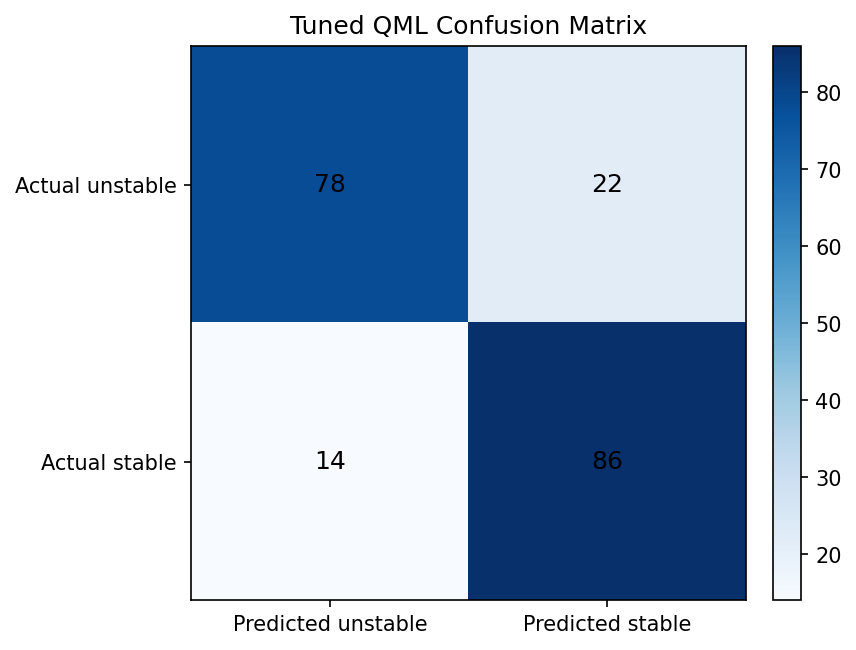

In [12]:
qml_confusion_matrix = confusion_matrix(tuned_true_labels, tuned_qml_predicted_labels, labels=[0, 1])
confusion_dataframe = pd.DataFrame(
    qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(qml_confusion_matrix, cmap="Blues")
plt.title("Tuned QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [13]:
sample_predictions_dataframe = tuned_qml_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "tuned_qml_predicted_label",
        "tuned_qml_stable_probability",
    ]
].head(10)
display(sample_predictions_dataframe)

material_id,formula,target_is_stable,tuned_qml_predicted_label,tuned_qml_stable_probability
mp-861915,LiDy2Ir,1,1,0.807657
mp-1191394,Li8Nd7Ge10,0,1,0.646342
mp-759724,Li3MnF7,0,0,0.224294
mp-37480,LiSbSe2,0,1,0.797944
mp-3203193,LiV(CuS2)2,1,1,0.879612
mp-3203521,BaSr2(LiSn2)4,1,1,0.648639
mp-1212343,Li22(Cu3Si2)7,1,1,0.846534
mp-1185354,LiGd2Os,1,1,0.838996
mp-776176,Li4Ti3V3(CuO8)2,0,0,0.221231
mp-758945,Li5CuHO4,0,1,0.534829


In [14]:
improved_best_result = improved_qml_tuning_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "cv_stable_recall"],
    ascending=[False, False, False],
).iloc[0]

improved_true_labels = improved_qml_predictions_dataframe["target_is_stable"]
improved_qml_predicted_labels = improved_qml_predictions_dataframe["improved_qml_predicted_label"]

improved_summary_dataframe = pd.DataFrame([
    {
        "section": "Improved QML separate section",
        "feature_preparation": "feature importance + PCA",
        "best_kernel": improved_best_result["kernel_name"],
        "best_qubits": int(improved_best_result["pca_component_count"]),
        "angle_scale": improved_best_result["angle_scale"],
        "svm_c": improved_best_result["c_value"],
        "cv_stable_f1": improved_best_result["cv_stable_f1"],
        "test_accuracy": accuracy_score(improved_true_labels, improved_qml_predicted_labels),
        "test_stable_f1": f1_score(improved_true_labels, improved_qml_predicted_labels, zero_division=0),
    }
]).round(4)

display(improved_summary_dataframe)

section,feature_preparation,best_kernel,best_qubits,angle_scale,svm_c,cv_stable_f1,test_accuracy,test_stable_f1
Improved QML separate section,feature importance + PCA,entangled_pi,6,pi,2.0,0.8596,0.815,0.823


predicted_unstable,predicted_stable
77,23
14,86


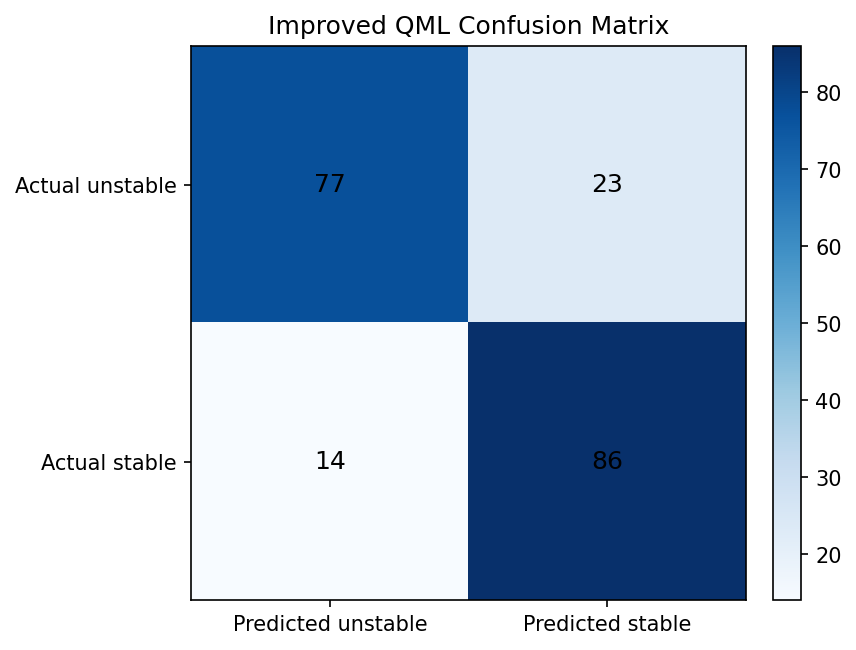

In [15]:
improved_qml_confusion_matrix = confusion_matrix(
    improved_true_labels,
    improved_qml_predicted_labels,
    labels=[0, 1],
)
improved_confusion_dataframe = pd.DataFrame(
    improved_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(improved_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(improved_qml_confusion_matrix, cmap="Blues")
plt.title("Improved QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, improved_qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [16]:
improved_sample_predictions_dataframe = improved_qml_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "improved_qml_predicted_label",
        "improved_qml_stable_probability",
    ]
].head(10)
display(improved_sample_predictions_dataframe)

material_id,formula,target_is_stable,improved_qml_predicted_label,improved_qml_stable_probability
mp-861915,LiDy2Ir,1,1,0.838005
mp-1191394,Li8Nd7Ge10,0,1,0.838534
mp-759724,Li3MnF7,0,1,0.711953
mp-37480,LiSbSe2,0,1,0.867497
mp-3203193,LiV(CuS2)2,1,1,0.861535
mp-3203521,BaSr2(LiSn2)4,1,1,0.840463
mp-1212343,Li22(Cu3Si2)7,1,1,0.869735
mp-1185354,LiGd2Os,1,1,0.837175
mp-776176,Li4Ti3V3(CuO8)2,0,0,0.134662
mp-758945,Li5CuHO4,0,0,0.144349


In [17]:
improved_best_threshold_result = improved_qml_threshold_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "cv_stable_recall"],
    ascending=[False, False, False],
).iloc[0]

threshold_true_labels = improved_qml_threshold_predictions_dataframe["target_is_stable"]
threshold_qml_predicted_labels = improved_qml_threshold_predictions_dataframe["threshold_qml_predicted_label"]

threshold_summary_dataframe = pd.DataFrame([
    {
        "section": "Threshold experiment",
        "selected_threshold": improved_best_threshold_result["stable_threshold"],
        "cv_stable_f1": improved_best_threshold_result["cv_stable_f1"],
        "test_accuracy": accuracy_score(threshold_true_labels, threshold_qml_predicted_labels),
        "test_stable_precision": precision_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
        "test_stable_recall": recall_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
        "test_stable_f1": f1_score(threshold_true_labels, threshold_qml_predicted_labels, zero_division=0),
    }
]).round(4)

display(threshold_summary_dataframe)

section,selected_threshold,cv_stable_f1,test_accuracy,test_stable_precision,test_stable_recall,test_stable_f1
Threshold experiment,0.5,0.8581,0.82,0.7963,0.86,0.8269


predicted_unstable,predicted_stable
78,22
14,86


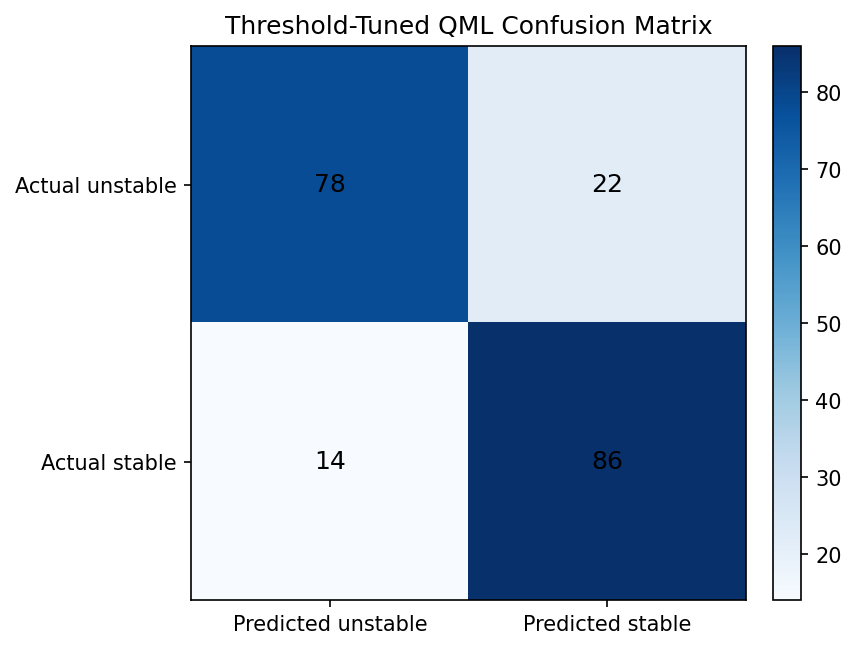

In [18]:
threshold_qml_confusion_matrix = confusion_matrix(
    threshold_true_labels,
    threshold_qml_predicted_labels,
    labels=[0, 1],
)
threshold_confusion_dataframe = pd.DataFrame(
    threshold_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(threshold_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(threshold_qml_confusion_matrix, cmap="Blues")
plt.title("Threshold-Tuned QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, threshold_qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [19]:
improved_best_alignment_result = improved_qml_alignment_results_dataframe.sort_values(
    by=["cv_stable_f1", "cv_accuracy", "kernel_target_alignment"],
    ascending=[False, False, False],
).iloc[0]

alignment_true_labels = improved_qml_alignment_predictions_dataframe["target_is_stable"]
alignment_qml_predicted_labels = improved_qml_alignment_predictions_dataframe["alignment_qml_predicted_label"]

alignment_summary_dataframe = pd.DataFrame([
    {
        "section": "Kernel alignment experiment",
        "feature_set": improved_best_alignment_result["feature_set_name"],
        "feature_count": int(improved_best_alignment_result["feature_count"]),
        "kernel": improved_best_alignment_result["kernel_name"],
        "angle_scale": improved_best_alignment_result["angle_scale"],
        "svm_c": improved_best_alignment_result["c_value"],
        "kernel_target_alignment": improved_best_alignment_result["kernel_target_alignment"],
        "cv_stable_f1": improved_best_alignment_result["cv_stable_f1"],
        "test_accuracy": accuracy_score(alignment_true_labels, alignment_qml_predicted_labels),
        "test_stable_f1": f1_score(alignment_true_labels, alignment_qml_predicted_labels, zero_division=0),
    }
]).round(4)

display(alignment_summary_dataframe)

section,feature_set,feature_count,kernel,angle_scale,svm_c,kernel_target_alignment,cv_stable_f1,test_accuracy,test_stable_f1
Kernel alignment experiment,rf_top_4,4,entangled_pi,pi,5.0,0.378537,0.8568,0.82,0.8302


predicted_unstable,predicted_stable
76,24
12,88


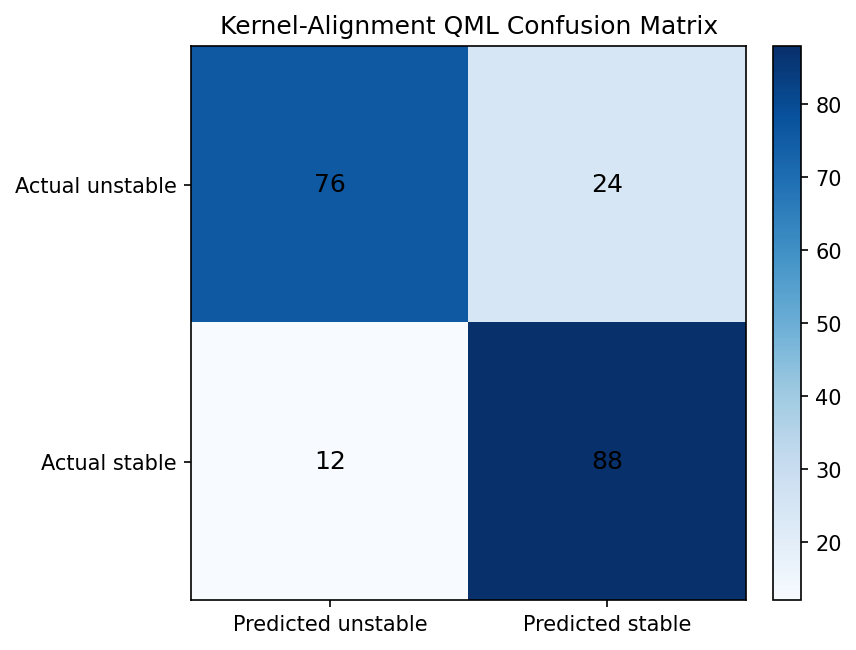

In [20]:
alignment_qml_confusion_matrix = confusion_matrix(
    alignment_true_labels,
    alignment_qml_predicted_labels,
    labels=[0, 1],
)
alignment_confusion_dataframe = pd.DataFrame(
    alignment_qml_confusion_matrix,
    index=["actual_unstable", "actual_stable"],
    columns=["predicted_unstable", "predicted_stable"],
)
display(alignment_confusion_dataframe)

plt.figure(figsize=(5.8, 4.8))
plt.imshow(alignment_qml_confusion_matrix, cmap="Blues")
plt.title("Kernel-Alignment QML Confusion Matrix")
plt.xticks([0, 1], ["Predicted unstable", "Predicted stable"])
plt.yticks([0, 1], ["Actual unstable", "Actual stable"])
for row_index in range(2):
    for column_index in range(2):
        plt.text(column_index, row_index, alignment_qml_confusion_matrix[row_index, column_index], ha="center", va="center")
plt.colorbar()
plt.show()

In [21]:
alignment_sample_predictions_dataframe = improved_qml_alignment_predictions_dataframe[
    [
        "material_id",
        "formula",
        "target_is_stable",
        "alignment_qml_predicted_label",
        "alignment_qml_stable_probability",
    ]
].head(10)
display(alignment_sample_predictions_dataframe)

material_id,formula,target_is_stable,alignment_qml_predicted_label,alignment_qml_stable_probability
mp-861915,LiDy2Ir,1,1,0.845221
mp-1191394,Li8Nd7Ge10,0,1,0.856232
mp-759724,Li3MnF7,0,1,0.704116
mp-37480,LiSbSe2,0,1,0.862706
mp-3203193,LiV(CuS2)2,1,1,0.873231
mp-3203521,BaSr2(LiSn2)4,1,1,0.861881
mp-1212343,Li22(Cu3Si2)7,1,1,0.823264
mp-1185354,LiGd2Os,1,1,0.838970
mp-776176,Li4Ti3V3(CuO8)2,0,0,0.129983
mp-758945,Li5CuHO4,0,0,0.129832


In [22]:
repeated_split_summary_rows = []
repeated_split_metric_columns = [
    "accuracy",
    "stable_precision",
    "stable_recall",
    "stable_f1",
]

for metric_name in repeated_split_metric_columns:
    repeated_split_summary_rows.append(
        {
            "metric": metric_name,
            "mean": best_qml_repeated_split_results_dataframe[metric_name].mean(),
            "standard_deviation": best_qml_repeated_split_results_dataframe[metric_name].std(ddof=1),
            "minimum": best_qml_repeated_split_results_dataframe[metric_name].min(),
            "maximum": best_qml_repeated_split_results_dataframe[metric_name].max(),
        }
    )

repeated_split_summary_dataframe = pd.DataFrame(repeated_split_summary_rows).round(4)
display(repeated_split_summary_dataframe)

metric,mean,standard_deviation,minimum,maximum
accuracy,0.8550,0.0220,0.8150,0.8900
stable_precision,0.8389,0.0266,0.8053,0.8854
stable_recall,0.8800,0.0394,0.8200,0.9600
stable_f1,0.8583,0.0223,0.8159,0.8972


In [23]:
qml_vs_logistic_comparison_rows = []
metric_names = ["accuracy", "stable_precision", "stable_recall", "stable_f1"]

for metric_name in metric_names:
    qml_mean = qml_vs_logistic_summary_dataframe[
        (qml_vs_logistic_summary_dataframe["model"] == "QML kernel classifier")
        & (qml_vs_logistic_summary_dataframe["metric"] == metric_name)
    ]["mean"].iloc[0]
    logistic_mean = qml_vs_logistic_summary_dataframe[
        (qml_vs_logistic_summary_dataframe["model"] == "Logistic Regression")
        & (qml_vs_logistic_summary_dataframe["metric"] == metric_name)
    ]["mean"].iloc[0]
    difference = qml_mean - logistic_mean
    if difference > 0:
        winner = "QML"
    elif difference < 0:
        winner = "Logistic Regression"
    else:
        winner = "Tie"

    qml_vs_logistic_comparison_rows.append(
        {
            "metric": metric_name,
            "qml_mean": round(qml_mean, 4),
            "logistic_mean": round(logistic_mean, 4),
            "qml_minus_logistic": round(difference, 4),
            "winner": winner,
        }
    )

qml_vs_logistic_comparison_dataframe = pd.DataFrame(qml_vs_logistic_comparison_rows)
display(qml_vs_logistic_comparison_dataframe)

metric,qml_mean,logistic_mean,qml_minus_logistic,winner
accuracy,0.8550,0.8410,0.0140,QML
stable_precision,0.8389,0.8144,0.0245,QML
stable_recall,0.8800,0.8840,-0.0040,Logistic Regression
stable_f1,0.8583,0.8473,0.0110,QML


In [24]:
display(Markdown("""# Presentation Conclusion

**What we achieved**

- Built a complete lithium battery material pipeline.
- Created India-focused material scoring and final shortlist.
- Added DSS recommendation rankings for battery families and material candidates.
- Trained XGBoost as the classical baseline.
- Prepared a balanced QML-ready dataset.
- Trained a first simulated quantum-kernel classifier.
- Tuned QML hyperparameters using 4-fold cross-validation.
- Added a separate improved-QML section using feature importance, PCA, and an
  entangled-kernel search.
- Added a threshold experiment for the improved-QML stable probability.
- Added a kernel-alignment experiment for quantum-aware feature selection.
- Validated the best QML setup across 10 random train/test splits.
- Compared best QML with Logistic Regression on the same repeated splits.
- Added a gate-level visual diagram for the best 4-qubit QML feature map.

**Main model result**

- QML accuracy on QML-ready test split: **0.8100**
- Tuned QML accuracy on QML-ready test split: **0.8200**
- Tuned QML stable F1 on QML-ready test split: **0.8269**
- Improved QML separate-section accuracy: **0.8150**
- Improved QML separate-section stable F1: **0.8230**
- Improved QML threshold-tuned accuracy: **0.8200**
- Improved QML threshold-tuned stable F1: **0.8269**
- Improved QML kernel-alignment accuracy: **0.8200**
- Improved QML kernel-alignment stable F1: **0.8302**
- Repeated-split mean accuracy: **0.8550**
- Repeated-split mean stable F1: **0.8583**
- QML vs Logistic mean accuracy: **0.8550 vs 0.8410**
- QML vs Logistic mean stable F1: **0.8583 vs 0.8473**
- Same-data XGBoost accuracy: **0.8300**

**Next step**

Write the final DSS-style interpretation for the top ranked battery families
and material candidates.
"""))

# Presentation Conclusion

**What we achieved**

- Built a complete lithium battery material pipeline.
- Created India-focused material scoring and final shortlist.
- Added DSS recommendation rankings for battery families and material candidates.
- Trained XGBoost as the classical baseline.
- Prepared a balanced QML-ready dataset.
- Trained a first simulated quantum-kernel classifier.
- Tuned QML hyperparameters using 4-fold cross-validation.
- Added a separate improved-QML section using feature importance, PCA, and an
  entangled-kernel search.
- Added a threshold experiment for the improved-QML stable probability.
- Added a kernel-alignment experiment for quantum-aware feature selection.
- Validated the best QML setup across 10 random train/test splits.
- Compared best QML with Logistic Regression on the same repeated splits.
- Added a gate-level visual diagram for the best 4-qubit QML feature map.

**Main model result**

- QML accuracy on QML-ready test split: **0.8100**
- Tuned QML accuracy on QML-ready test split: **0.8200**
- Tuned QML stable F1 on QML-ready test split: **0.8269**
- Improved QML separate-section accuracy: **0.8150**
- Improved QML separate-section stable F1: **0.8230**
- Improved QML threshold-tuned accuracy: **0.8200**
- Improved QML threshold-tuned stable F1: **0.8269**
- Improved QML kernel-alignment accuracy: **0.8200**
- Improved QML kernel-alignment stable F1: **0.8302**
- Repeated-split mean accuracy: **0.8550**
- Repeated-split mean stable F1: **0.8583**
- QML vs Logistic mean accuracy: **0.8550 vs 0.8410**
- QML vs Logistic mean stable F1: **0.8583 vs 0.8473**
- Same-data XGBoost accuracy: **0.8300**

**Next step**

Write the final DSS-style interpretation for the top ranked battery families
and material candidates.
